### SVM Kernels Indepth Intuition And Practical Explanation

In [88]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
print(y)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

[8.66025404 8.71779204 8.77378994 8.82827705 8.88128118 8.93282873
 8.98294476 9.03165312 9.07897646 9.12493632 9.16955321 9.21284664
 9.25483518 9.29553652 9.3349675  9.37314414 9.41008171 9.44579475
 9.4802971  9.51360192 9.54572176 9.57666854 9.60645359 9.63508769
 9.66258107 9.68894344 9.714184   9.73831149 9.76133416 9.7832598
 9.80409577 9.82384901 9.84252604 9.86013297 9.87667553 9.89215905
 9.90658851 9.91996849 9.93230325 9.94359667 9.9538523  9.96307334
 9.97126266 9.9784228  9.98455598 9.98966408 9.99374868 9.99681104
 9.99885209 9.99987246 9.99987246 9.99885209 9.99681104 9.99374868
 9.98966408 9.98455598 9.9784228  9.97126266 9.96307334 9.9538523
 9.94359667 9.93230325 9.91996849 9.90658851 9.89215905 9.87667553
 9.86013297 9.84252604 9.82384901 9.80409577 9.7832598  9.76133416
 9.73831149 9.714184   9.68894344 9.66258107 9.63508769 9.60645359
 9.57666854 9.54572176 9.51360192 9.4802971  9.44579475 9.41008171
 9.37314414 9.3349675  9.29553652 9.25483518 9.21284664 9.169553

In [89]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
print(y1,-y1)

x1=np.hstack([x1,-x1])


[ 0.          0.99994898  1.40690791  1.71419826  1.96904936  2.18984681
  2.38606299  2.563349    2.72540153  2.87479787  3.01342099  3.14269681
  3.26373625  3.37742495  3.48448249  3.5855029   3.68098326  3.77134438
  3.85694608  3.93809873  4.0150721   4.08810229  4.1573971   4.2231404
  4.28549564  4.34460872  4.40061029  4.45361771  4.50373673  4.55106276
  4.59568209  4.63767284  4.67710582  4.71404521  4.7485492   4.78067053
  4.81045693  4.83795152  4.86319318  4.88621682  4.90705366  4.92573145
  4.94227468  4.95670471  4.96903995  4.97929598  4.98748561  4.99361903
  4.99770379  4.99974492  4.99974492  4.99770379  4.99361903  4.98748561
  4.97929598  4.96903995  4.95670471  4.94227468  4.92573145  4.90705366
  4.88621682  4.86319318  4.83795152  4.81045693  4.78067053  4.7485492
  4.71404521  4.67710582  4.63767284  4.59568209  4.55106276  4.50373673
  4.45361771  4.40061029  4.34460872  4.28549564  4.2231404   4.1573971
  4.08810229  4.0150721   3.93809873  3.85694608  3.77

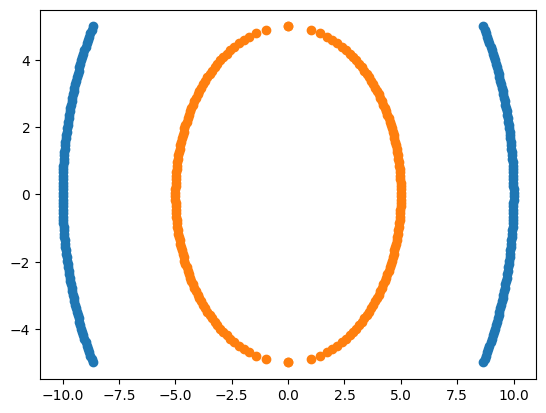

In [90]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [91]:

import numpy as np
import pandas as pd
df1 = pd.DataFrame(np.vstack([y, x]).T, columns=['X1', 'X2'])
df1['Y'] = 0
df2 = pd.DataFrame(np.vstack([y1, x1]).T, columns=['X1', 'X2'])
df2['Y'] = 1
# df = df1.append(df2)
df = pd.concat([df1, df2], ignore_index=True)

In [92]:
### Independent and Dependent features
X = df.iloc[:, :2]  
y = df['Y']
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [93]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [94]:
## Split the dataset into train and test
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [95]:
y_train

247    1
110    0
16     0
66     0
153    0
      ..
71     0
106    0
270    1
348    1
102    0
Name: Y, Length: 300, dtype: int64

In [96]:
from sklearn.svm import SVC
classifier=SVC(kernel="rbf")
classifier.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [97]:
from sklearn.metrics import accuracy_score
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [98]:
df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


### Polynomial Kernel
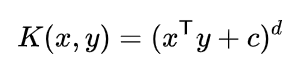

In [99]:
# We need to find components for the Polynomical Kernel
#X1,X2,X1_square,X2_square,X1*X2
df['X1_Square']= df['X1']**2
df['X2_Square']= df['X2']**2
df['X1*X2'] = (df['X1'] *df['X2'])
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [100]:
### Independent and Dependent features
X = df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y = df['Y']

In [101]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [102]:

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 0)


In [103]:
X_train

,X1,X2,X1_Square,X2_Square,X1*X2
250,4.999745,0.050505,24.997449,0.002551,0.252512
63,9.906589,1.363636,98.140496,1.859504,13.508984
312,-3.263736,3.787879,10.651974,14.348026,-12.362637
159,-9.953852,-0.959596,99.079176,0.920824,9.551676
283,3.680983,3.383838,13.549638,11.450362,12.455852
...,...,...,...,...,...
323,-4.223140,2.676768,17.834915,7.165085,-11.304366
192,-9.031653,-4.292929,81.570758,18.429242,38.772248
117,-9.445795,3.282828,89.223038,10.776962,-31.008922
47,9.996811,-0.252525,99.936231,0.063769,-2.524447


In [104]:
import plotly.express as px

fig = px.scatter_3d(df, x='X1', y='X2', z='X1*X2',
              color='Y')
fig.show()

In [107]:

fig = px.scatter_3d(df, x='X1_Square', y='X2_Square', z='X1*X2',
              color='Y')
fig.show()

In [108]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [109]:
from sklearn.linear_model import LogisticRegression

In [110]:
class_reg = LogisticRegression()

In [113]:
class_reg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [114]:
y_pred = class_reg.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

Text(0.5, 0, 'X1*X2')

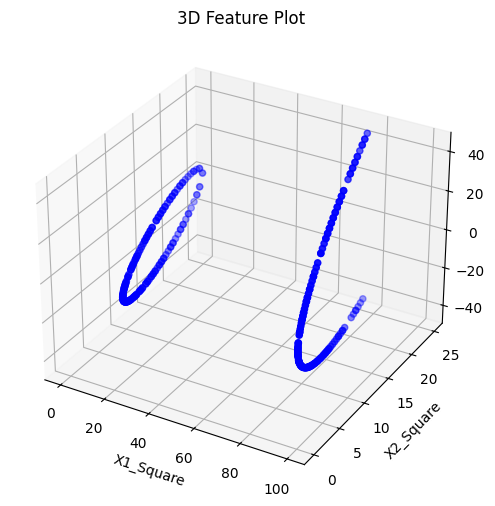

In [123]:
# Example: 3D scatter using X1_Square, X2_Square, and X1*X2 from the polynomial features DataFrame
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_train["X1_Square"], X_train["X2_Square"], X_train["X1*X2"], c='b', marker='o')

ax.set_title("3D Feature Plot")
ax.set_xlabel("X1_Square")
ax.set_ylabel("X2_Square")
ax.set_zlabel("X1*X2")

In [119]:
ax.plot_surface(X1, X2, X1X2, cmap="viridis", alpha=0.8)


NameError: name 'X1' is not defined